In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset crudo en CSV
df = pd.read_csv("../data/raw/base_de_datos.csv")

# 1. Ajustar tipos de datos
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'])
df['tipo_credito'] = df['tipo_credito'].astype('category')
df['tipo_laboral'] = df['tipo_laboral'].astype('category')
df['Pago_atiempo'] = df['Pago_atiempo'].astype(int)

# 2. Unificar inconsistencias en 'tendencia_ingresos'
categorias_validas = ['Estable', 'Creciente', 'Decreciente']
df['tendencia_ingresos'] = df['tendencia_ingresos'].apply(
    lambda x: x if x in categorias_validas else np.nan
).astype('category')

# 3. Ver resumen de nulos
print("--- Conteo de Valores Nulos ---")
print(df.isnull().sum())

--- Conteo de Valores Nulos ---
tipo_credito                        0
fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                     0
total_otros_prestamos               0
cuota_pactada                       0
puntaje                             0
puntaje_datacredito                 6
cant_creditosvigentes               0
huella_consulta                     0
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2930
tendencia_ingresos               2990
Pago_atiempo                        0
dtype: int64


In [2]:
# Variables numéricas
num_cols = df.select_dtypes(include=[np.number]).columns

stats = pd.DataFrame({
    'media': df[num_cols].mean(),
    'mediana': df[num_cols].median(),
    'desv_est': df[num_cols].std(),
    'IQR': df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25),
    'min': df[num_cols].min(),
    'max': df[num_cols].max(),
    'asimetria': df[num_cols].skew(),
    'curtosis': df[num_cols].kurtosis()
})

display(stats)

,media,mediana,desv_est,IQR,min,max,asimetria,curtosis
capital_prestado,2.434315e+06,1.921920e+06,1.909643e+06,1860009.00,360000.00000,4.144415e+07,3.723884,35.318092
plazo_meses,1.057558e+01,1.000000e+01,6.632082e+00,6.00,2.00000,9.000000e+01,2.459691,7.780121
edad_cliente,4.394862e+01,4.200000e+01,1.506088e+01,20.00,19.00000,1.230000e+02,1.934399,7.868936
salario_cliente,1.721643e+07,3.000000e+06,3.554767e+08,2875808.00,0.00000,2.200000e+10,43.776664,2211.230120
total_otros_prestamos,6.238870e+06,1.000000e+06,1.184183e+08,1500000.00,0.00000,6.787675e+09,38.463886,1719.280871
cuota_pactada,2.436174e+05,1.828630e+05,2.104937e+05,166792.00,23944.00000,3.816752e+06,3.793301,26.650757
puntaje,9.117004e+01,9.522779e+01,1.646544e+01,0.00,-38.00999,9.522779e+01,-4.865607,24.081011
puntaje_datacredito,7.807908e+02,7.910000e+02,1.048780e+02,68.00,-7.00000,9.990000e+02,-5.644513,39.437798
cant_creditosvigentes,5.726749e+00,5.000000e+00,3.977162e+00,5.00,0.00000,6.200000e+01,1.797738,8.623346
huella_consulta,4.228561e+00,4.000000e+00,3.064683e+00,4.00,0.00000,2.900000e+01,1.487102,3.998984


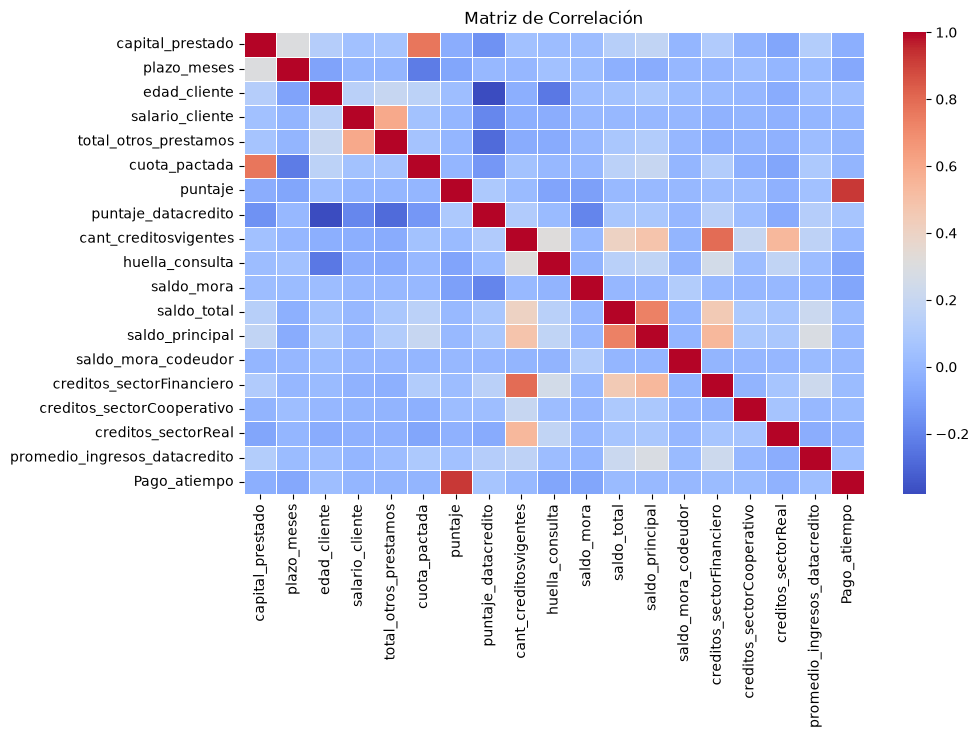

C:\Users\camil\AppData\Local\Temp\ipykernel_27536\1525875075.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pago_atiempo', y='puntaje_datacredito', palette='Set2')


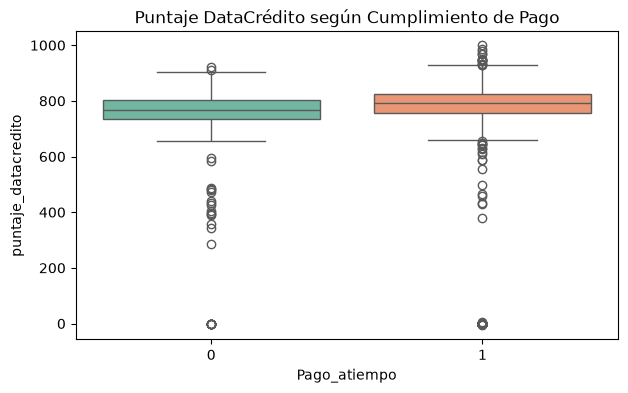

In [3]:
# Matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

# Boxplot Puntaje vs Pago a Tiempo
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Pago_atiempo', y='puntaje_datacredito', palette='Set2')
plt.title('Puntaje DataCrédito según Cumplimiento de Pago')
plt.show()